In [1]:
import yfinance as yf
import pandas as pd, numpy as np
import xgboost as xgb, lightgbm as lgb
import ta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_sample_weight
warnings.filterwarnings("ignore")

In [2]:
def evaluate_model(y_true, y_pred, model_name):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    return {
        "model": model_name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
    }

In [3]:
def train_base_model(X_train, y_train, X_valid=None, y_valid=None, model_name="LOG"):
    sc = None
    train_weights = compute_sample_weight('balanced', y_train)
    val_weights = compute_sample_weight('balanced', y_valid)
    if model_name == "LOG":
        sc = StandardScaler()
        model = LogisticRegression(class_weight="balanced", max_iter=1000)
        X_train_scaled = sc.fit_transform(X_train)
        model.fit(X_train_scaled, y_train)
    elif model_name == "XGB":
        model = xgb.XGBClassifier(n_estimators=1000, early_stopping_rounds=50, objective="binary:logistic", learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8)
        model.fit(X_train,y_train,eval_set=[(X_valid, y_valid)],verbose=False,sample_weight=train_weights, sample_weight_eval_set=[val_weights])
    elif model_name == 'LGB':
        model = lgb.LGBMClassifier(n_estimators=1000, random_state=1, objective="binary", class_weight="balanced")
        model.fit(X_train,y_train,eval_set=[(X_valid, y_valid)], callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])
    return model, sc

In [4]:
TICKER = 'BTC-USD'
PERIOD = "3y"
Ticker = yf.Ticker(ticker=f'{TICKER}')
df = Ticker.history(PERIOD)
start = df.index.min()
end = df.index.max()
sample_size = len(df)
df.drop(columns=['Dividends','Stock Splits'], inplace=True)
print(f'✅ Downloaded {TICKER} data from {start} to {end}, total bars: {sample_size}')

✅ Downloaded BTC-USD data from 2023-04-04 00:00:00+00:00 to 2026-04-04 00:00:00+00:00, total bars: 1097


In [5]:
df["SMA9"] = df["Close"].rolling(window=9).mean()
df["SMA25"] = df["Close"].rolling(window=25).mean()
df["Volatility9"] = df["Close"].rolling(window=9).std()
df["Volatility25"] = df["Close"].rolling(window=25).std()
df["Support_Level_short"] = df["Close"].rolling(window=25).min()
df["Resistance_Level_short"] = df["Close"].rolling(window=25).max()
df["Close_SMA9_ratio"] = (df["Close"] - df["SMA9"]) / df["SMA9"]
df["Close_SMA25_ratio"] = (df["Close"] - df["SMA25"]) / df["SMA25"]
rsi = ta.momentum.RSIIndicator(close=df["Close"])
df["RSI"] = rsi.rsi()
macd = ta.trend.MACD(close=df["Close"])
df["MACD"] = macd.macd()
df["Signal_Line"] = macd.macd_signal()
df["MACD_Diff"] = ta.trend.macd_diff(df["Close"])
for lag in [1, 2, 3, 5, 7, 9, 25]:
    df[f"Price_Change_{lag}d"] = df["Close"].pct_change(lag)
    df[f"Vol_Change_{lag}d"] = df["Volume"].pct_change(lag)
df["Price_Change_5d_later"] = df["Price_Change_5d"].shift(-5)
# df.loc[df["Price_Change_5d_later"] >= 0.04, "Target"] = 0  # Buy
# df.loc[df["Price_Change_5d_later"] <= -0.04, "Target"] = 2  # Sell
# df.loc[df["Target"].isna(), "Target"] = 1  # Hold
df["Target"] = (df["Close"].shift(-5) > df["Close"]).astype(int)
#df['Target'] = df['Target'].shift(-1) ##### >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> Comment this line if it doens't make sense
df.dropna(inplace=True)
print(f"✅ Technical indicators calculated...")
print(f'✅ Data cleaned...')

✅ Technical indicators calculated...
✅ Data cleaned...


In [6]:
target_labels = {0:'Down', 1:'Up'}
class_weights = df['Target'].value_counts(normalize=True).sort_index().to_dict()

print(f'✅ Target variable added, class weights:')
for k, v in class_weights.items():
    print(f"{target_labels[k]} {v:.0%}")

✅ Target variable added, class weights:
Down 47%
Up 53%


In [7]:
features = ['Volume',
            # 'Close_SMA9_ratio',
            # 'Close_SMA25_ratio',
            'RSI',
            'MACD',
            'Signal_Line',
            'Volatility9', 'Volatility25',
            'Price_Change_1d', 'Vol_Change_1d', 'Price_Change_2d', 'Vol_Change_2d',
            'Price_Change_3d', 'Vol_Change_3d', 'Price_Change_5d', 'Vol_Change_5d', 'Price_Change_7d', 'Vol_Change_7d', 'Price_Change_9d', 'Vol_Change_9d',
            'Price_Change_25d', 'Vol_Change_25d'
            ]

In [8]:
train_end_date = "2025-06-30"

train_data = df[:train_end_date]
test_data = df[train_end_date:]
X_train, y_train = train_data[features], train_data["Target"]
X_test, y_test = test_data[features], test_data["Target"]
train_size = len(X_train)
test_size = len(X_test)
print(f"✅ Data split done. Train: {train_size}, Test: {test_size}")

✅ Data split done. Train: 786, Test: 274


In [9]:
splits = 5
tscv = TimeSeriesSplit(n_splits=splits)
metrics = []
for train_idx, valid_idx in tscv.split(X_train, y_train):
    x_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    x_va, y_va = X_train.iloc[valid_idx], y_train.iloc[valid_idx]

    xgb_cl, _ = train_base_model(x_tr, y_tr, x_va, y_va, model_name="XGB")
    y_pred = xgb_cl.predict(x_va)
    results = evaluate_model(y_va, y_pred, "XGB")
    metrics.append(results)
print("Cross Validation Results:\n", pd.DataFrame(metrics).to_string(max_colwidth=50))

Cross Validation Results:
   model  precision    recall        f1      confusion_matrix
0   XGB   0.521739  0.473684  0.496552  [[22, 33], [40, 36]]
1   XGB   0.666667  0.300000  0.413793  [[39, 12], [56, 24]]
2   XGB   0.485294  0.492537  0.488889  [[29, 35], [34, 33]]
3   XGB   0.645161  0.540541  0.588235  [[35, 22], [34, 40]]
4   XGB   0.580247  0.594937  0.587500  [[18, 34], [32, 47]]


In [11]:
# Train full model on full train_val data 80:20

train_sample_size = int(X_train.shape[0] * 0.8)
x_tr, y_tr = X_train.iloc[:train_sample_size], y_train.iloc[:train_sample_size]
x_va, y_va = X_train.iloc[train_sample_size:], y_train.iloc[train_sample_size:]
xgb_cl, _ = train_base_model(x_tr, y_tr, x_va, y_va, model_name="XGB")
y_pred = xgb_cl.predict(x_va)
results = evaluate_model(y_va, y_pred, "XGB")
print("Full data validation Results:\n", pd.DataFrame([results]).to_string(max_colwidth=50))

Full data validation Results:
   model  precision    recall        f1      confusion_matrix
0   XGB    0.53125  0.573034  0.551351  [[24, 45], [38, 51]]


In [12]:
y_test_pred = xgb_cl.predict(X_test)
test_results = evaluate_model(y_test, y_test_pred, "XGB")
print("Test Results:\n", pd.DataFrame([test_results]).to_string(max_colwidth=50))

Test Results:
   model  precision  recall        f1       confusion_matrix
0   XGB   0.449541   0.784  0.571429  [[29, 120], [27, 98]]


In [13]:
print('Test Prediction Class proportions:')
print(pd.Series(y_test_pred).value_counts(normalize=True).sort_index())

Test Prediction Class proportions:
0    0.20438
1    0.79562
Name: proportion, dtype: float64


In [14]:
df_test = test_data.copy()
df_test["pred"] = y_test_pred

# Correct mapping
signal_map = {0: -1, 1: 1}
df_test["signal"] = df_test["pred"].map(signal_map)

# Returns
df_test["ret"] = df_test["Close"].pct_change()

# Apply with lag
df_test["strategy_ret"] = df_test["signal"].shift(1) * df_test["ret"]

# Performance
cum_return = (1 + df_test["strategy_ret"]).cumprod()
sharpe = df_test["strategy_ret"].mean() / df_test["strategy_ret"].std() * np.sqrt(252)

print("Sharpe:", sharpe)

Sharpe: -0.1205749086231894


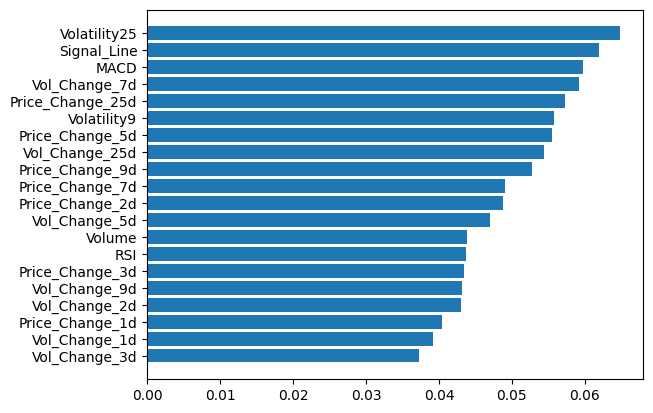

In [15]:
feature_importances = pd.DataFrame(
    {
        'Feature': X_train.columns,
        'Importance': xgb_cl.feature_importances_
    }
).sort_values(by='Importance', ascending=True)
plt.barh(feature_importances['Feature'], feature_importances['Importance'])
plt.show()

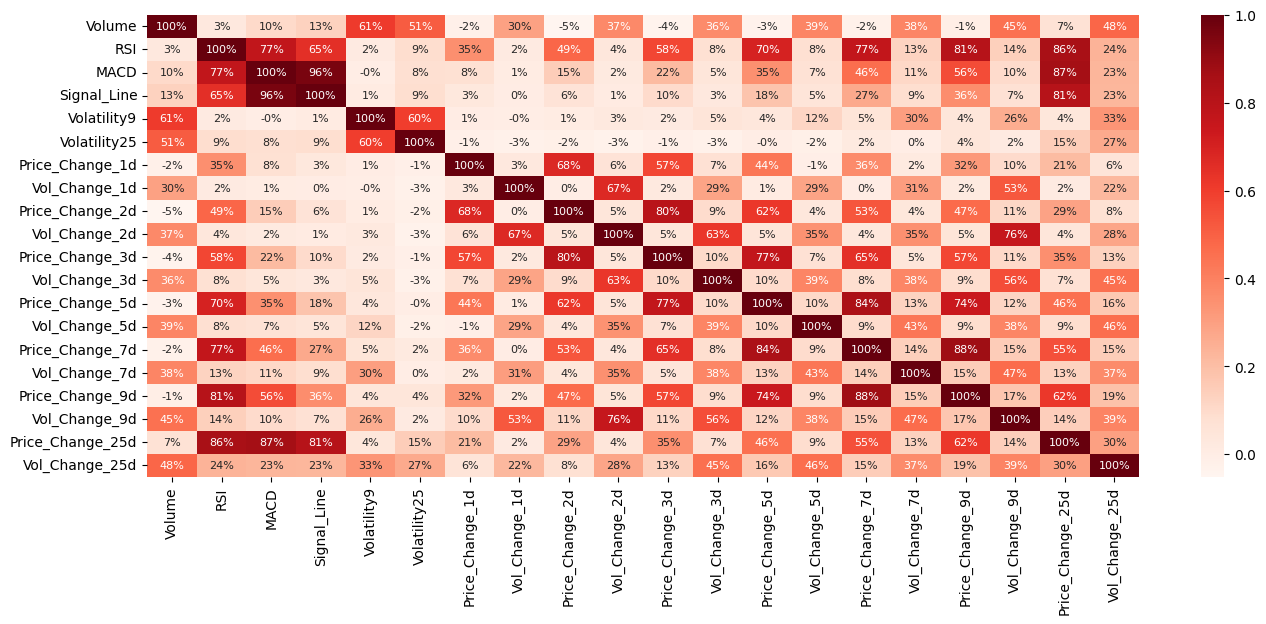

In [16]:
plt.figure(figsize=(16, 6))
sns.heatmap(
    df[features].corr(), cmap="Reds", fmt="0.0%", annot=True, annot_kws={"size": 8}
)
plt.show()